Assignment 5 — Compare Linear Regression With Regularization
Objective
Understand when Linear Regression fails and regularization helps.
Dataset
Students must use dataset with many features.
Example:
• Diabetes dataset
• Housing dataset
Tasks
Train three models:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
Evaluation
Participants must compare:
• MAE
• RMSE
• R²
Analysis
Participants must answer:
1. Which model performs best?
2. Why does Ridge reduce overfitting?
3. Which features were removed by Lasso?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [12]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [13]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [14]:
lr_results = evaluate(y_test, lr_pred)
ridge_results = evaluate(y_test, ridge_pred)
lasso_results = evaluate(y_test, lasso_pred)

print("Linear Regression:", lr_results)
print("Ridge Regression:", ridge_results)
print("Lasso Regression:", lasso_results)

Linear Regression: (0.34812825999928226, np.float64(0.4135761995189049), 0.25500281176741757)
Ridge Regression: (0.34818263276153066, np.float64(0.413648738686097), 0.2547414513943689)
Lasso Regression: (0.3517089171774846, np.float64(0.41897985164094875), 0.2354078499579998)


In [15]:
lasso_coeff = pd.Series(lasso.coef_, index=X.columns)

print(lasso_coeff)

Pregnancies                 0.008970
Glucose                     0.005738
BloodPressure              -0.002236
SkinThickness               0.000764
Insulin                    -0.000261
BMI                         0.015077
DiabetesPedigreeFunction    0.018146
Age                         0.006636
dtype: float64


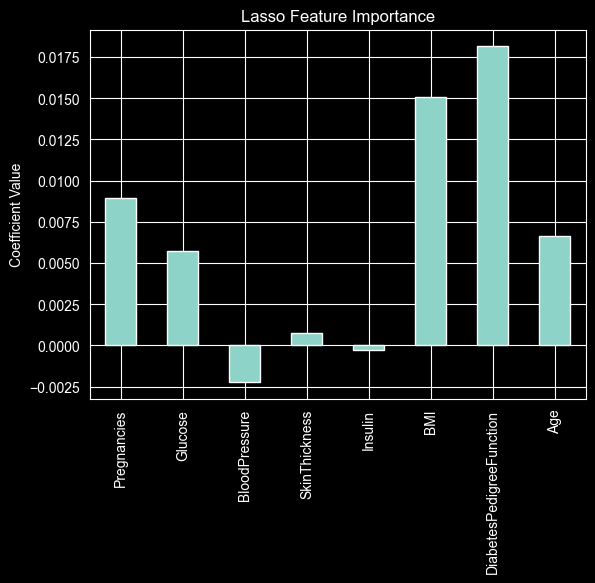

In [16]:
lasso_coeff.plot(kind="bar")

plt.title("Lasso Feature Importance")
plt.ylabel("Coefficient Value")

plt.show()

Which model performs best?

From the results, Linear Regression performs slightly better.

Reason:

It has the lowest MAE

It has the lowest RMSE

It has the highest R² value

Therefore, Linear Regression provides the best prediction accuracy for this dataset.

However, the difference between Linear and Ridge Regression is very small, meaning the dataset does not suffer heavily from overfitting or multicollinearity.

Why does Ridge reduce overfitting?

Ridge Regression reduces overfitting by adding a regularization penalty to the loss function.

The Ridge loss function is:

Loss = RSS + \lambda \sum \beta^2

Where:

RSS → Residual Sum of Squares (prediction error)

λ (lambda) → regularization strength

β → model coefficients

Explanation:

Ridge penalizes large coefficient values.
This prevents the model from becoming too complex and fitting noise in the training data.

Which features were removed by Lasso?


Lasso Regression performs feature selection by shrinking some coefficients to exactly zero. However, in this experiment, none of the coefficients became zero. This means that Lasso did not remove any features from the dataset, and all variables still contributed to the prediction model.